In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# EMNIST 'balanced' split contains 47 classes
# We use standard transforms: ToTensor and Normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("Downloading and loading EMNIST balanced dataset...")
train_dataset = torchvision.datasets.EMNIST(root='./data', split='balanced', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.EMNIST(root='./data', split='balanced', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)
print(f"Train dataset size: {len(train_dataset)}, Test dataset size: {len(test_dataset)}")

100%|██████████| 562M/562M [00:03<00:00, 155MB/s]


Train dataset size: 112800, Test dataset size: 18800


In [ ]:
# Load ResNet18 (without pretrained weights since we are adapting it heavily for 28x28 grayscale)
model = resnet18(weights=None)

# Modify the first convolutional layer to accept 1 channel (grayscale) instead of 3
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# The EMNIST balanced dataset has 47 classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 47)

# Move the model to the chosen device (GPU/CPU)
model = model.to(device)

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 50
patience = 5
best_val_acc = 0.0
epochs_no_improve = 0

resnet18_train_acc = []
resnet18_val_acc = []

print("Starting training loop...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, data in enumerate(train_loader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:    # print every 100 mini-batches
            print(f'[Epoch {epoch + 1}, Batch {i + 1:4d}] loss: {running_loss / 100:.3f}, accuracy: {100 * correct / total:.2f}%')
            running_loss = 0.0

    train_acc = 100 * correct / total
    resnet18_train_acc.append(train_acc)

    # Validation phase
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data in test_loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    resnet18_val_acc.append(val_acc)
    print(f'--- Epoch {epoch+1} Validation Accuracy: {val_acc:.2f}% ---')

    # Early stopping logic
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(
            f"  No improvement ({epochs_no_improve}/{patience}) | Best test acc: {best_val_acc:.2f}%"
        )
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print('Finished Training')

Starting training loop...
[Epoch 1, Batch  100] loss: 0.203, accuracy: 91.89%
[Epoch 1, Batch  200] loss: 0.217, accuracy: 91.66%
[Epoch 1, Batch  300] loss: 0.207, accuracy: 91.70%
[Epoch 1, Batch  400] loss: 0.199, accuracy: 91.67%
[Epoch 1, Batch  500] loss: 0.206, accuracy: 91.66%
[Epoch 1, Batch  600] loss: 0.213, accuracy: 91.57%
[Epoch 1, Batch  700] loss: 0.214, accuracy: 91.55%
--- Epoch 1 Validation Accuracy: 88.76% ---
[Epoch 2, Batch  100] loss: 0.188, accuracy: 92.20%
[Epoch 2, Batch  200] loss: 0.178, accuracy: 92.35%
[Epoch 2, Batch  300] loss: 0.185, accuracy: 92.33%
[Epoch 2, Batch  400] loss: 0.189, accuracy: 92.30%
[Epoch 2, Batch  500] loss: 0.195, accuracy: 92.27%
[Epoch 2, Batch  600] loss: 0.190, accuracy: 92.25%
[Epoch 2, Batch  700] loss: 0.201, accuracy: 92.16%
--- Epoch 2 Validation Accuracy: 88.79% ---
[Epoch 3, Batch  100] loss: 0.164, accuracy: 93.34%
[Epoch 3, Batch  200] loss: 0.160, accuracy: 93.36%
[Epoch 3, Batch  300] loss: 0.177, accuracy: 93.19%
[E

In [ ]:
import torch.nn as nn
from torchvision.models import resnet50

# Load ResNet50 (without pretrained weights)
model_res50 = resnet50(weights=None)

# Modify the first convolutional layer to accept 1 channel (grayscale) instead of 3
model_res50.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# The EMNIST balanced dataset has 47 classes
num_ftrs_50 = model_res50.fc.in_features
model_res50.fc = nn.Linear(num_ftrs_50, 47)

# Move the model to the chosen device (GPU/CPU)
model_res50 = model_res50.to(device)
print("ResNet50 model initialized and adapted for EMNIST!")

ResNet50 model initialized and adapted for EMNIST!


In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion_res50 = nn.CrossEntropyLoss()
optimizer_res50 = optim.Adam(model_res50.parameters(), lr=0.001)

num_epochs_res50 = 25
patience_res50 = 5
best_val_acc_res50 = 0.0
epochs_no_improve_res50 = 0

resnet50_train_acc = []
resnet50_val_acc = []

print("Starting ResNet50 training loop...")

for epoch in range(num_epochs_res50):
    model_res50.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, data in enumerate(train_loader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer_res50.zero_grad()

        outputs = model_res50(inputs)
        loss = criterion_res50(outputs, labels)
        loss.backward()
        optimizer_res50.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:    # print every 100 mini-batches
            print(f'[Epoch {epoch + 1}, Batch {i + 1:4d}] loss: {running_loss / 100:.3f}, accuracy: {100 * correct / total:.2f}%')
            running_loss = 0.0

    train_acc = 100 * correct / total
    resnet50_train_acc.append(train_acc)

    # Validation phase
    model_res50.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data in test_loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model_res50(inputs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    resnet50_val_acc.append(val_acc)
    print(f'--- Epoch {epoch+1} Validation Accuracy: {val_acc:.2f}% ---')

    # Early stopping logic
    if val_acc > best_val_acc_res50:
        best_val_acc_res50 = val_acc
        epochs_no_improve_res50 = 0
    else:
        epochs_no_improve_res50 += 1
        print(
            f"  No improvement ({epochs_no_improve_res50}/{patience_res50}) | Best test acc: {best_val_acc_res50:.2f}%"
        )
        if epochs_no_improve_res50 >= patience_res50:
            print(f"Early stopping at epoch {epoch+1}")
            break

print('Finished ResNet50 Training')

Starting ResNet50 training loop...
[Epoch 1, Batch  100] loss: 2.349, accuracy: 39.52%
[Epoch 1, Batch  200] loss: 1.068, accuracy: 53.31%
[Epoch 1, Batch  300] loss: 0.772, accuracy: 60.46%
[Epoch 1, Batch  400] loss: 0.657, accuracy: 64.84%
[Epoch 1, Batch  500] loss: 0.612, accuracy: 67.83%
[Epoch 1, Batch  600] loss: 0.568, accuracy: 70.02%
[Epoch 1, Batch  700] loss: 0.581, accuracy: 71.66%
[Epoch 1, Batch  800] loss: 0.635, accuracy: 72.84%
--- Epoch 1 Validation Accuracy: 82.47% ---
[Epoch 2, Batch  100] loss: 0.489, accuracy: 83.84%
[Epoch 2, Batch  200] loss: 0.410, accuracy: 84.86%
[Epoch 2, Batch  300] loss: 0.429, accuracy: 84.85%
[Epoch 2, Batch  400] loss: 0.422, accuracy: 84.96%
[Epoch 2, Batch  500] loss: 0.418, accuracy: 85.04%
[Epoch 2, Batch  600] loss: 0.409, accuracy: 85.15%
[Epoch 2, Batch  700] loss: 0.440, accuracy: 85.20%
[Epoch 2, Batch  800] loss: 0.402, accuracy: 85.30%
--- Epoch 2 Validation Accuracy: 85.10% ---
[Epoch 3, Batch  100] loss: 0.351, accuracy: 

Generating confusion matrix for ResNet50...


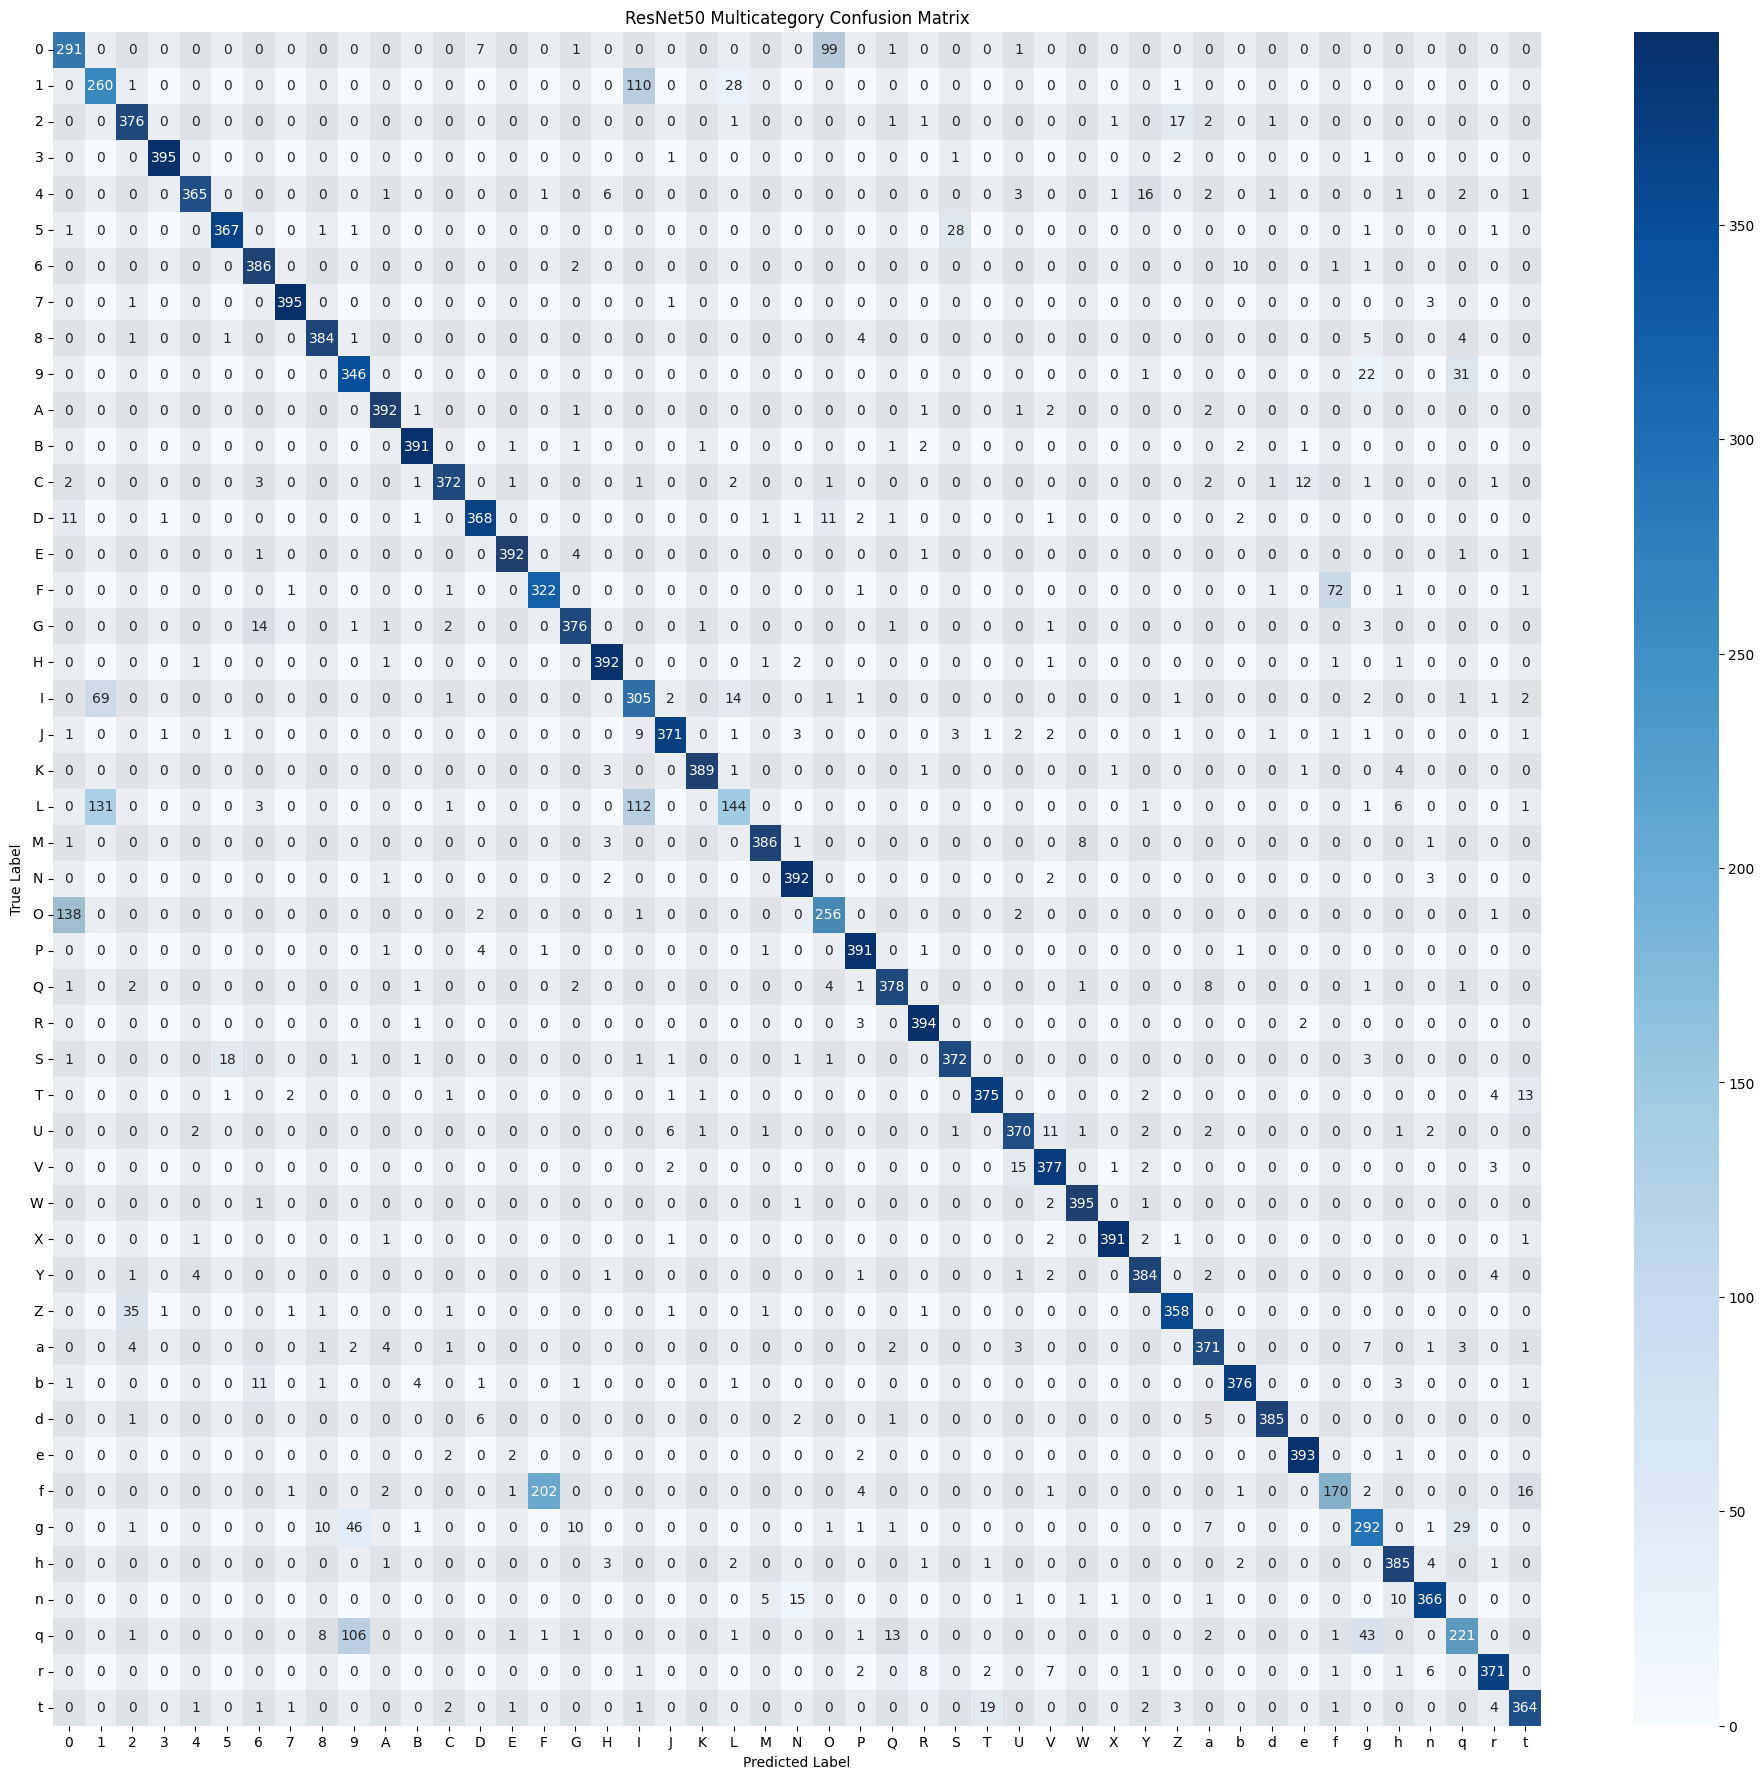

Confusion matrix generated.


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

print("Generating confusion matrix for ResNet50...")

all_preds = []
all_labels = []

model_res50.eval() # Set model to evaluation mode
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_res50(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Get class names from the dataset (EMNIST balanced classes)
class_names = test_dataset.classes

# Plotting the confusion matrix
plt.figure(figsize=(24, 22))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=class_names, yticklabels=class_names)

# Visually distinguish every other row and column (Zebra striping)
for i in range(len(class_names)):
    if i % 2 == 0:
        # Add translucent horizontal stripe
        ax.add_patch(patches.Rectangle((0, i), len(class_names), 1, fill=True, color='gray', alpha=0.1, lw=0))
        # Add translucent vertical stripe
        ax.add_patch(patches.Rectangle((i, 0), 1, len(class_names), fill=True, color='gray', alpha=0.1, lw=0))

plt.title('ResNet50 Multicategory Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()
print("Confusion matrix generated.")

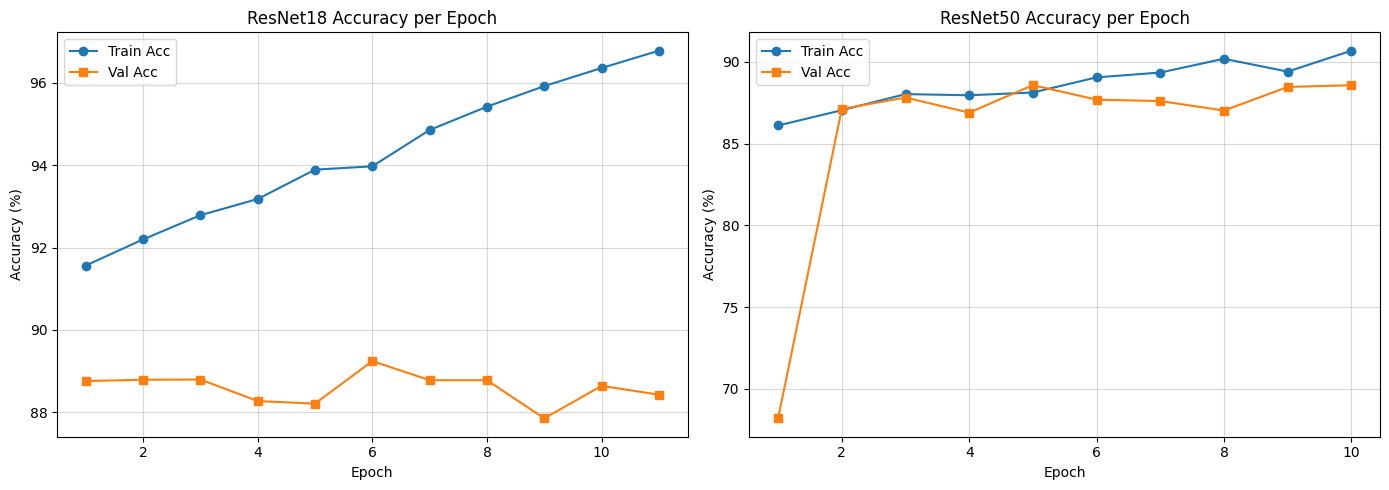

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# ResNet18 Plot
plt.subplot(1, 2, 1)
plt.plot(range(1, len(resnet18_train_acc) + 1), resnet18_train_acc, label='Train Acc', marker='o')
plt.plot(range(1, len(resnet18_val_acc) + 1), resnet18_val_acc, label='Val Acc', marker='s')
plt.title('ResNet18 Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.5)

# ResNet50 Plot
plt.subplot(1, 2, 2)
plt.plot(range(1, len(resnet50_train_acc) + 1), resnet50_train_acc, label='Train Acc', marker='o')
plt.plot(range(1, len(resnet50_val_acc) + 1), resnet50_val_acc, label='Val Acc', marker='s')
plt.title('ResNet50 Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

100%|██████████| 562M/562M [00:02<00:00, 192MB/s]


Device: cuda
Epoch 1/50 | Loss: 1.2566 | Acc: 63.98% | LR: 0.001000
Epoch 2/50 | Loss: 0.5374 | Acc: 82.02% | LR: 0.000999
Epoch 3/50 | Loss: 0.4504 | Acc: 84.45% | LR: 0.000996
Epoch 4/50 | Loss: 0.4115 | Acc: 85.47% | LR: 0.000991
Epoch 5/50 | Loss: 0.3797 | Acc: 86.35% | LR: 0.000984
Epoch 6/50 | Loss: 0.3565 | Acc: 87.15% | LR: 0.000976
Epoch 7/50 | Loss: 0.3393 | Acc: 87.74% | LR: 0.000965
Epoch 8/50 | Loss: 0.3259 | Acc: 88.08% | LR: 0.000952
Epoch 9/50 | Loss: 0.3151 | Acc: 88.40% | LR: 0.000938
  No improvement (1/5) | Best test acc: 86.45%
Epoch 10/50 | Loss: 0.3047 | Acc: 88.73% | LR: 0.000922
Epoch 11/50 | Loss: 0.2934 | Acc: 89.04% | LR: 0.000905
  No improvement (1/5) | Best test acc: 87.03%
Epoch 12/50 | Loss: 0.2833 | Acc: 89.34% | LR: 0.000885
Epoch 13/50 | Loss: 0.2743 | Acc: 89.69% | LR: 0.000864
Epoch 14/50 | Loss: 0.2648 | Acc: 89.92% | LR: 0.000842
  No improvement (1/5) | Best test acc: 87.31%
Epoch 15/50 | Loss: 0.2576 | Acc: 90.12% | LR: 0.000819
Epoch 16/50 | L

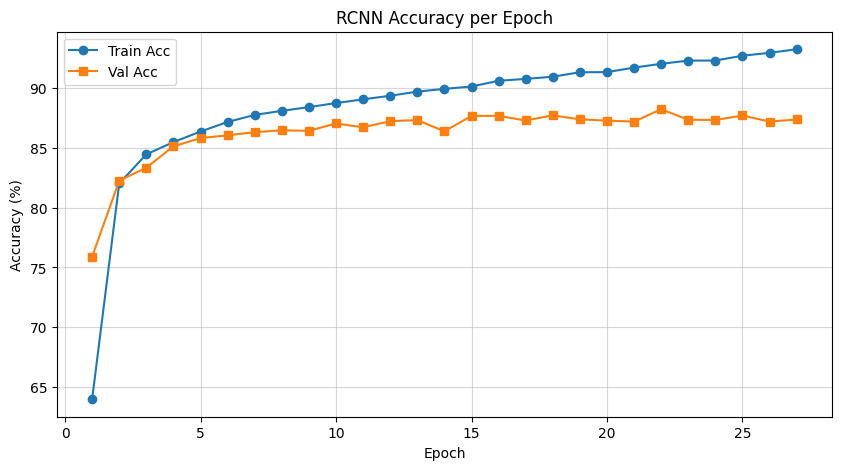

In [ ]:
# Phl Lanes - RCNN Model for EMNIST Balanced Character Recognition
# -------------------------------------------------------
# Features:
#   - Patch-based image splitting (image divided into horizontal strips)
#   - CNN feature extraction per patch (multi-layer with batch normalization)
#   - LSTM sequential modeling across patches
#   - Mixed precision training (float16 via torch.amp)
#   - Cosine annealing learning rate scheduling
#   - Early stopping with best model checkpointing
#   - CSV logging of hyperparameters and results per run
#   - GPU accelerated (CUDA) with optimized DataLoader pipeline
# --------------------------------------------------------
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import time
import csv
import os
from datetime import datetime
import matplotlib.pyplot as plt

# Changeable but not recommended
CONST_NUM_PATCHES = 7  # Number of vertical patches to split the image into

# --- Hyperparameters ---
FILTERS = 64  # Number of convolutional filters
HIDDEN_SIZE = 256  # Size of the LSTM hidden state
NUM_LAYERS = 2  # Number of LSTM layers
DROPOUT = 0.4  # Dropout rate for regularization
LR = 0.001  # Learning rate for the optimizer
EPOCHS = 50
NUM_CLASSES = 47

# --- Early Stopping ---
PATIENCE = 5  # Stop if no improvement after this many epochs

# --- Performance Parameters ---
BATCH_SIZE = 512  # Size of each training batch
NUM_WORKERS = 4  # Number of subprocesses for data loading
PREFETCH_FACTOR = 4  # Number of batches to prefetch

# -------------------
LOG_FILE = "results.csv"


def log_results(label, train_acc, test_acc, epochs_run):
    RESULTS_DIR = "models/RCNN/results"
    os.makedirs(RESULTS_DIR, exist_ok=True)

    file_path = os.path.join(RESULTS_DIR, LOG_FILE)
    file_exists = os.path.exists(file_path)
    with open(file_path, "a", newline="") as f:
        writer = csv.writer(f)

        if not file_exists:
            writer.writerow(
                [
                    "timestamp",
                    "label",
                    "num_patches",
                    "filters",
                    "hidden_size",
                    "num_layers",
                    "dropout",
                    "batch_size",
                    "lr",
                    "epochs_run",
                    "patience",
                    "train_acc",
                    "test_acc",
                    "device",
                ]
            )

        writer.writerow(
            [
                datetime.now().strftime("%Y-%m-%d %H:%M"),
                label,
                CONST_NUM_PATCHES,
                FILTERS,
                HIDDEN_SIZE,
                NUM_LAYERS,
                DROPOUT,
                BATCH_SIZE,
                LR,
                epochs_run,
                PATIENCE,
                f"{train_acc:.2f}",
                f"{test_acc:.2f}",
                str(device),
            ]
        )


start_time = time.time()

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
)

# Fixed path to work in Notebook environments
root = "./data"

train_dataset = datasets.EMNIST(
    root=root, split="balanced", train=True, download=True, transform=transform
)
test_dataset = datasets.EMNIST(
    root=root, split="balanced", train=False, download=True, transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=PREFETCH_FACTOR,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=PREFETCH_FACTOR,
)


def get_cnn_out_size(cnn, num_patches):
    patch_h = 28 // num_patches
    dummy = torch.zeros(1, 1, patch_h, 28)
    return cnn(dummy).shape[1]


class RCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.num_patches = CONST_NUM_PATCHES
        patch_h = 28 // CONST_NUM_PATCHES

        self.cnn = nn.Sequential(
            nn.Conv2d(1, FILTERS, kernel_size=3, padding=1),
            nn.BatchNorm2d(FILTERS),
            nn.ReLU(),
            nn.Conv2d(FILTERS, FILTERS * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(FILTERS * 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(FILTERS * 2, FILTERS * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(FILTERS * 4),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
        )
        cnn_out_size = get_cnn_out_size(self.cnn, CONST_NUM_PATCHES)
        self.rnn = nn.LSTM(
            input_size=cnn_out_size,
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,
            batch_first=True,
            dropout=DROPOUT if NUM_LAYERS > 1 else 0,
        )
        self.dropout = nn.Dropout(DROPOUT)
        self.fc = nn.Linear(HIDDEN_SIZE, NUM_CLASSES)

    def forward(self, x):
        patch_h = 28 // self.num_patches
        patches = x.unfold(2, patch_h, patch_h)
        patches = patches.permute(0, 2, 1, 4, 3)
        cnn_out = torch.stack(
            [self.cnn(patches[:, i]) for i in range(self.num_patches)], dim=1
        )
        out, _ = self.rnn(cnn_out)
        return self.fc(self.dropout(out[:, -1]))


model = RCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler("cuda" if torch.cuda.is_available() else "cpu")


def train(epochs=EPOCHS):
    best_acc = 0
    no_improve = 0
    final_acc = 0
    epochs_run = 0

    train_hist = []
    val_hist = []

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            if torch.cuda.is_available():
                with torch.amp.autocast("cuda"):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        final_acc = 100 * correct / total
        train_hist.append(final_acc)

        current_lr = scheduler.get_last_lr()[0]
        scheduler.step()
        epochs_run = epoch + 1

        print(
            f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Acc: {final_acc:.2f}% | LR: {current_lr:.6f}"
        )

        # Early stopping
        test_acc = evaluate(silent=True)
        val_hist.append(test_acc)

        if test_acc > best_acc:
            best_acc = test_acc
            no_improve = 0
            torch.save(model.state_dict(), "best_model.pt")
        else:
            no_improve += 1
            print(
                f"  No improvement ({no_improve}/{PATIENCE}) | Best test acc: {best_acc:.2f}%"
            )
            if no_improve >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # Load best model before final evaluation
    model.load_state_dict(torch.load("best_model.pt"))
    return final_acc, epochs_run, train_hist, val_hist


def evaluate(silent=False):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    acc = 100 * correct / total
    if not silent:
        print(f"Test Accuracy: {acc:.2f}%")
    return acc


if __name__ == "__main__":
    print("Device:", device)
    label = "rcnn_unlabeled" # Removed input() to prevent notebook blocking

    train_acc, epochs_run, train_hist, val_hist = train(epochs=EPOCHS)
    test_acc = evaluate()
    log_results(label, train_acc, test_acc, epochs_run)
    end_time = time.time()
    print(f"Total execution time: {end_time - start_time:.2f} seconds")
    print(f"Results saved to {LOG_FILE}")
    train_loader._iterator = None
    test_loader._iterator = None

    # Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, epochs_run + 1), train_hist, label='Train Acc', marker='o')
    plt.plot(range(1, epochs_run + 1), val_hist, label='Val Acc', marker='s')
    plt.title('RCNN Accuracy per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.show()
